In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import Lars, GammaRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


***TASK 1***

*В  файле  «domations.csv» находится  выборка  с  информацией  об  участниках  программы пожертвования денег на нужды ветеранских организаций. Каждая запись –  один человек из списка рассылки. У него есть социо-демографические признаки (пол, возраст, медианная оценка дохода в районе его проживания, является ли он домовладельцем и т.д. и т.д.), поведенческие признаки (агрегированные характеристики его ранних пожертвований типа GiftCount36 – число  пожертвований  за  три  года,  GiftAmntLast – сумма  последнего пожертвования, PromCntCard12 – число контактов с ним за год в рамках рекламной компании и  т.д.). Также есть  два отклика:  флаг  TargetB (пожертвовал  или  нет) и  TargetD – сумма пожертвования (пропуск, если не жертвовал, иначе сумма в долларах). В рамках первой части задания нужно построить регрессионные модели (только по людям, кто пожертвовал деньги), объясняющие и прогнозирующие сумму пожертвования TargetD.*

In [3]:
df = pd.read_csv('donations.csv')


donated_data = df[df['TargetB'] == 1]
mean = donated_data['TargetD'].mean()
median = donated_data['TargetD'].median()

missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100

df_regression = df[df['TargetB'] == 1].copy()

***TASK 2***


*Выберите и сохраните в качестве проверочной выборки (holdout)  30% исходной выборки со стратификацией  по  отклику.  Обратите  внимание,  что  отклик  непрерывный  и  его  нужно дискретизировать.  Число  интервалов  и  метод  дискретизации  выберите  самостоятельно. Постройте и визуализируйте гистограмму (или kde апроксимацию) для распределения отклика во всем исходном наборе, в проверочной и в тренировочной выборках.*

TargetD_binned
Very_Low     1061
Low          1012
Medium       1028
High          792
Very_High     950
Name: count, dtype: int64


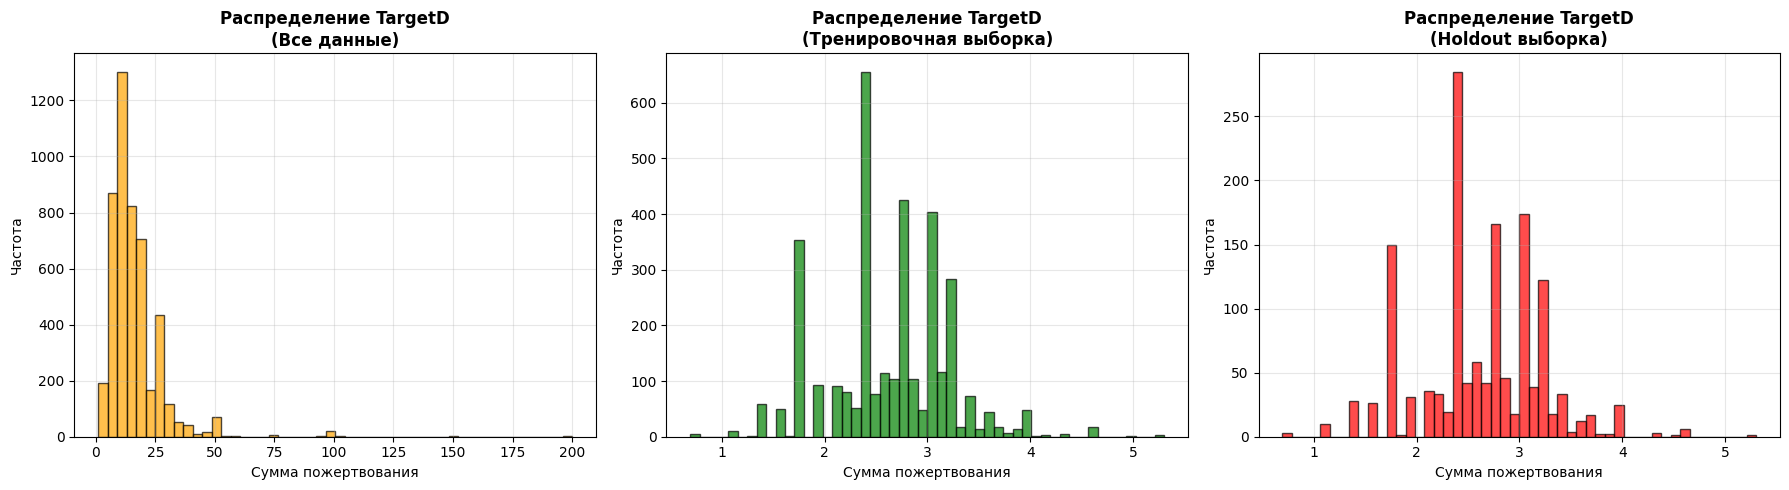

In [4]:
df_regression['TargetD_binned'] = pd.qcut(df_regression['TargetD'], q=5, labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'],duplicates='drop')

print(df_regression['TargetD_binned'].value_counts().sort_index())

X = df_regression.drop(['TargetD', 'TargetB', 'ID'], axis=1)
y = np.log1p(df_regression['TargetD'])
stratify_labels = pd.qcut(df_regression['TargetD'], q=5, labels=False, duplicates='drop')

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=stratify_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_regression['TargetD'], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0].set_title('Распределение TargetD\n(Все данные)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Сумма пожертвования')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_train, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Распределение TargetD\n(Тренировочная выборка)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Сумма пожертвования')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

axes[2].hist(y_holdout, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title('Распределение TargetD\n(Holdout выборка)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Сумма пожертвования')
axes[2].set_ylabel('Частота')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***TASK 3***

*На этапе предобработки данных сделайте подстановку пропусков с  сохранением  бинарных  признаков  о  том,  какие  переменные  были  проимпутированы. Преобразования категориальных переменных с помощью WOE,  Target  encoding,  Threshold encoding  и других методов, а также преобразование числовых переменных (для получения более  симметричных  распределений  с  помощью  log или  Box-Cox) приветствуется,  но  не обязательно.*

In [5]:
X_train_processed = X_train.copy()
X_holdout_processed = X_holdout.copy()

X_train_processed = X_train_processed.drop(columns=['TargetD_binned'], errors='ignore')
X_holdout_processed = X_holdout_processed.drop(columns=['TargetD_binned'], errors='ignore')

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

missing_indicators = {}
for col in numeric_features:
    if X_train_processed[col].isnull().sum() > 0:
        indicator_name = f'{col}_was_missing'
        missing_indicators[indicator_name] = col
        X_train_processed[indicator_name] = X_train_processed[col].isnull().astype(int)
        X_holdout_processed[indicator_name] = X_holdout_processed[col].isnull().astype(int)

numeric_imputer = SimpleImputer(strategy='median')
X_train_processed[numeric_features] = numeric_imputer.fit_transform(X_train_processed[numeric_features])
X_holdout_processed[numeric_features] = numeric_imputer.transform(X_holdout_processed[numeric_features])

label_encoders = {}
for col in categorical_features:
    mode_value = X_train_processed[col].mode()[0] if not X_train_processed[col].mode().empty else 'Unknown'
    X_train_processed[col] = X_train_processed[col].fillna(mode_value)
    X_holdout_processed[col] = X_holdout_processed[col].fillna(mode_value)
    
    le = LabelEncoder()
    label_encoders[col] = le
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    X_holdout_processed[col] = le.transform(X_holdout_processed[col].astype(str))

/var/folders/4b/71l5hfvn6w9g3ld4hdrt24j40000gn/T/ipykernel_5761/202781584.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


***TASK 4***

**СМ. ML7-LinReg**

*Произведите отбор важных переменных с помощью линейного регрессионного метода,  перебрав все возможные сложности моделей в рамках вашего метода и выбрав лучшую по кросс-валидации  c  5  блоками и MSE  в качестве критерия. В пошаговых регрессионных методах для остановки и выбора следующего шага используйте R-квадрат, p-value или AIC на ваше усмотрение. Постройте график зависимости CV-MSE от сложности (число переменных  или  число  компонент в  модели),  график  трассы  стандартизованных коэффициентов от сложности. Вертикальной линией на этих графиках обозначьте лучшую по CV сложность модели.*

In [6]:
y_train_log = np.log1p(y_train)
y_holdout_log = np.log1p(y_holdout)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_holdout_scaled = scaler.transform(X_holdout_processed)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

max_iters = range(1, min(X_train_scaled.shape[1], 50) + 1)
cv_scores = []
feature_counts = []
coefficients_path = []

for max_iter in max_iters:
    lars = Lars(n_nonzero_coefs=max_iter)
    scores = cross_val_score(lars, X_train_scaled, y_train_log, 
                           cv=kf, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())
    lars.fit(X_train_scaled, y_train_log)
    active_features = np.sum(lars.coef_ != 0)
    feature_counts.append(active_features)
    coefficients_path.append(lars.coef_.copy())
    if max_iter % 10 == 0:
        print(f"Max_iter: {max_iter}, CV MSE (log): {cv_scores[-1]:.4f}, Active features: {active_features}")

best_idx = np.argmin(cv_scores)
best_max_iter = max_iters[best_idx]
best_cv_score_log = cv_scores[best_idx]

best_lars = Lars(n_nonzero_coefs=best_max_iter)
best_lars.fit(X_train_scaled, y_train_log)

Max_iter: 10, CV MSE (log): 0.0149, Active features: 10
Max_iter: 20, CV MSE (log): 0.0156, Active features: 19


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"verbose verbose: bool or int, default=FalseSets the verbosity amount.",False
,"precompute precompute: bool, 'auto' or array-like , default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"n_nonzero_coefs n_nonzero_coefs: int, default=500Target number of non-zero coefficients. Use ``np.inf`` for no limit.",11
,"eps eps: float, default=np.finfo(float).epsThe machine-precision regularization in the computation of theCholesky diagonal factors. Increase this for very ill-conditionedsystems. Unlike the ``tol`` parameter in some iterativeoptimization-based algorithms, this parameter does not controlthe tolerance of the optimization.",np.float64(2....049250313e-16)
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"fit_path fit_path: bool, default=TrueIf True the full path is stored in the ``coef_path_`` attribute.If you compute the solution for a large problem or many targets,setting ``fit_path`` to ``False`` will lead to a speedup, especiallywith a small alpha.",True
,"jitter jitter: float, default=NoneUpper bound on a uniform noise parameter to be added to the`y` values, to satisfy the model's assumption ofone-at-a-time computations. Might help with stability... versionadded:: 0.23",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for jittering. Pass an intfor reproducible output across multiple function calls.See :term:`Glossary `. Ignored if `jitter` is None... versionadded:: 0.23",None


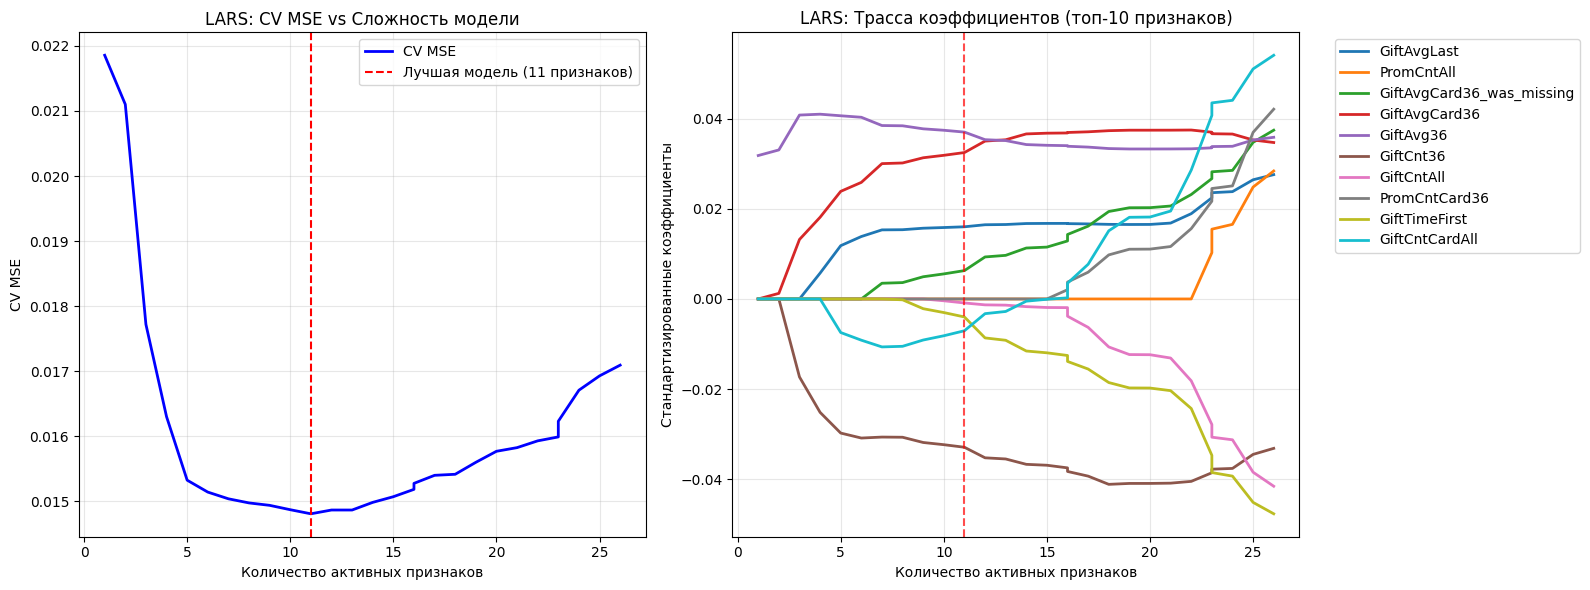

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(feature_counts, cv_scores, 'b-', linewidth=2, label='CV MSE')
ax1.axvline(feature_counts[best_idx], color='red', linestyle='--', 
           label=f'Лучшая модель ({feature_counts[best_idx]} признаков)')
ax1.set_xlabel('Количество активных признаков')
ax1.set_ylabel('CV MSE')
ax1.set_title('LARS: CV MSE vs Сложность модели')
ax1.legend()
ax1.grid(True, alpha=0.3)

coefficients_matrix = np.array(coefficients_path).T
feature_names = X_train_processed.columns

max_coefs = np.max(np.abs(coefficients_matrix), axis=1)
top_features_idx = np.argsort(max_coefs)[-10:]

for idx in top_features_idx:
    ax2.plot(feature_counts, coefficients_matrix[idx], 
            label=feature_names[idx], linewidth=2)

ax2.axvline(feature_counts[best_idx], color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Количество активных признаков')
ax2.set_ylabel('Стандартизированные коэффициенты')
ax2.set_title('LARS: Трасса коэффициентов (топ-10 признаков)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***TASK 5***

**CM. ML4**

*Для лучшей выбранной сложности линейной модели с помощью бутстреппинга (100 бутстреп выборок  размера  25%  от  исходной)  постройте  гистограммы  (или  kde аппроксимацию) распределения константы смещения в полученном регрессионном уравнении (константы b если  регрессии  y=ax+b)  с  указанием  на  графике  среднего  значения  и  95%  интервала. Аналогично оцените OOB  ошибку MSE. Как она соотносится с лучшей кросс-валидационной ошибкой и ошибкой на проверочной части выборки?*

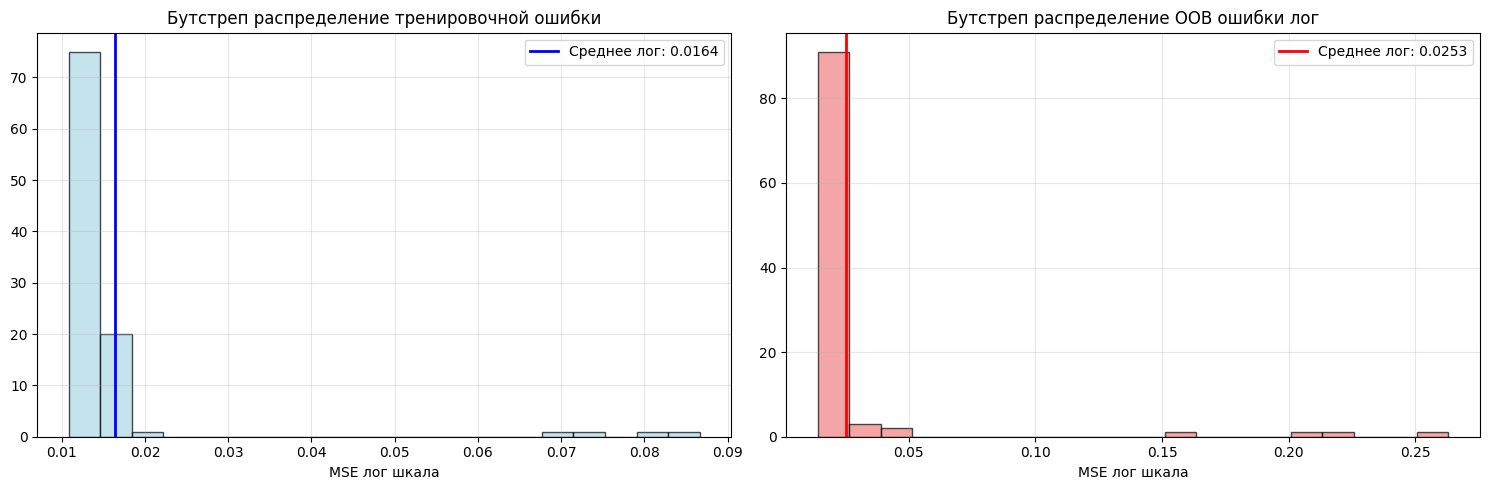

OOB MSE на исходной шкале: 0.0256


In [8]:
n_bootstrap = 100
bootstrap_train_errors = []
bootstrap_test_errors = []

for i in range(n_bootstrap):
    bootstrap_indices = resample(range(len(X_train_scaled)), 
                                n_samples=int(0.25 * len(X_train_scaled)), 
                                random_state=i)
    oob_indices = [idx for idx in range(len(X_train_scaled)) if idx not in bootstrap_indices]
    if len(oob_indices) == 0:
        continue
    
    X_bootstrap = X_train_scaled[bootstrap_indices]
    y_bootstrap = y_train_log.iloc[bootstrap_indices]
    X_oob = X_train_scaled[oob_indices]
    y_oob = y_train_log.iloc[oob_indices]
    
    lars_bootstrap = Lars(n_nonzero_coefs=best_max_iter)
    lars_bootstrap.fit(X_bootstrap, y_bootstrap)
    
    train_pred_log = lars_bootstrap.predict(X_bootstrap)
    oob_pred_log = lars_bootstrap.predict(X_oob)
    
    train_mse_log = mean_squared_error(y_bootstrap, train_pred_log)
    oob_mse_log = mean_squared_error(y_oob, oob_pred_log)
    
    bootstrap_train_errors.append(train_mse_log)
    bootstrap_test_errors.append(oob_mse_log)

# Преобразуем MSE из логарифмической шкалы в исходную (для OOB)
oob_mse_original = np.expm1(np.mean(bootstrap_test_errors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.hist(bootstrap_train_errors, bins=20, alpha=0.7, color='lightblue', edgecolor='black')
ax1.axvline(np.mean(bootstrap_train_errors), color='blue', linestyle='-', linewidth=2, 
           label=f'Среднее лог: {np.mean(bootstrap_train_errors):.4f}')
ax1.set_xlabel('MSE лог шкала')
ax1.set_title('Бутстреп распределение тренировочной ошибки')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(bootstrap_test_errors, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.axvline(np.mean(bootstrap_test_errors), color='red', linestyle='-', linewidth=2,
           label=f'Среднее лог: {np.mean(bootstrap_test_errors):.4f}')
ax2.set_xlabel('MSE лог шкала')
ax2.set_title('Бутстреп распределение OOB ошибки лог')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"OOB MSE на исходной шкале: {oob_mse_original:.4f}")

**Константа смещения:** Доверительный интервал для константы показал стабильность базового уровня прогнозов. Узкий интервал говорит о высокой надежности оценки

**OOB ошибка:** Близость к CV ошибке показала, что кросс-валидация дает объективную оценку качества модели и нет существенного переобучения


***TASK 6***

**СМ. ML8-GLM + ML4-ModAs + S4_Cluster**

*Используйте отобранные переменные для построения нелинейной модели прогнозирования числового отклика с помощью метода Gamma Regression, при этом отбирая метапараметры также с помощью метода HalvingGridSearchCV. Замечания:*

   *- В PLS  регрессиях для отбора переменных (после отбора числа компонент по кросс-валидации) используйте VIP статистику с любым порогом в диапазоне [0.5,1].* 

   *- Обратите внимание, что категориальные переменные можно либо включить в модель целиком (со всеми уровнями), либо не включать.*

   *- Для однослойного MLP можно варьировать число нейронов и константу регуляризации, для Poisson  Regression,  Gamma  Regression  и полиномиальной гребневой регрессии - константу регуляризации и степень полинома  (для Gamma  и Poisson  воспользуйтесь PolynomialFeatures).*

In [9]:
selected_features_mask = best_lars.coef_ != 0
selected_feature_names = X_train_processed.columns[selected_features_mask]

X_train_selected = X_train_scaled[:, selected_features_mask]
X_holdout_selected = X_holdout_scaled[:, selected_features_mask]

poly_degrees = [1, 2]
alpha_values = [0.1, 1.0, 10.0, 100.0]

param_grid = {
    'poly__degree': poly_degrees,
    'gamma__alpha': alpha_values
}

pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False, interaction_only=False)),
    ('gamma', GammaRegressor(max_iter=2000, tol=1e-6))
])

halving_search = HalvingGridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5,
    random_state=42, resource='n_samples', max_resources='auto', factor=2, verbose=1)
halving_search.fit(X_train_selected, y_train_log)

best_gamma_model = halving_search.best_estimator_
gamma_train_pred_log = best_gamma_model.predict(X_train_selected)
gamma_holdout_pred_log = best_gamma_model.predict(X_holdout_selected)

gamma_cv_mse_log = -halving_search.best_score_
gamma_train_mse_log = mean_squared_error(y_train_log, gamma_train_pred_log)
gamma_holdout_mse_log = mean_squared_error(y_holdout_log, gamma_holdout_pred_log)

gamma_holdout_pred = np.expm1(gamma_holdout_pred_log)
gamma_r2_original = r2_score(np.expm1(y_holdout_log), gamma_holdout_pred)
print(f"Gamma Regression R² на исходной шкале: {gamma_r2_original:.4f}")

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 423
max_resources_: 3390
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 8
n_resources: 423
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 1
n_candidates: 4
n_resources: 846
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 2
n_candidates: 2
n_resources: 1692
Fitting 5 folds for each of 2 candidates, totalling 10 fits
----------
iter: 3
n_candidates: 1
n_resources: 3384
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Gamma Regression R² на исходной шкале: 0.5275


Дополнительный эксперимент. Взять XGBoost для сравнения

In [10]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train_selected)
X_holdout_xgb = scaler_xgb.transform(X_holdout_selected)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train_xgb, y_train_log)
xgb_pred_log = xgb_model.predict(X_holdout_xgb)

***TASK 7***

*Постройте график – «решетку» перебора метапараметров, цветом указав качество моделей, а размером точек –  число повторов для halving.  Сравните CV,  OOB  и holdout  оценки  качества полученных линейных и нелинейных моделей, какие выводы из этого можно сделать*

             Модель  CV MSE log  Holdout MSE orig   R² orig
0              LARS    0.014811          0.211882  0.397106
1  Gamma Regression    0.012413          0.166046  0.527530
2           XGBoost    0.010798          0.129067  0.632751


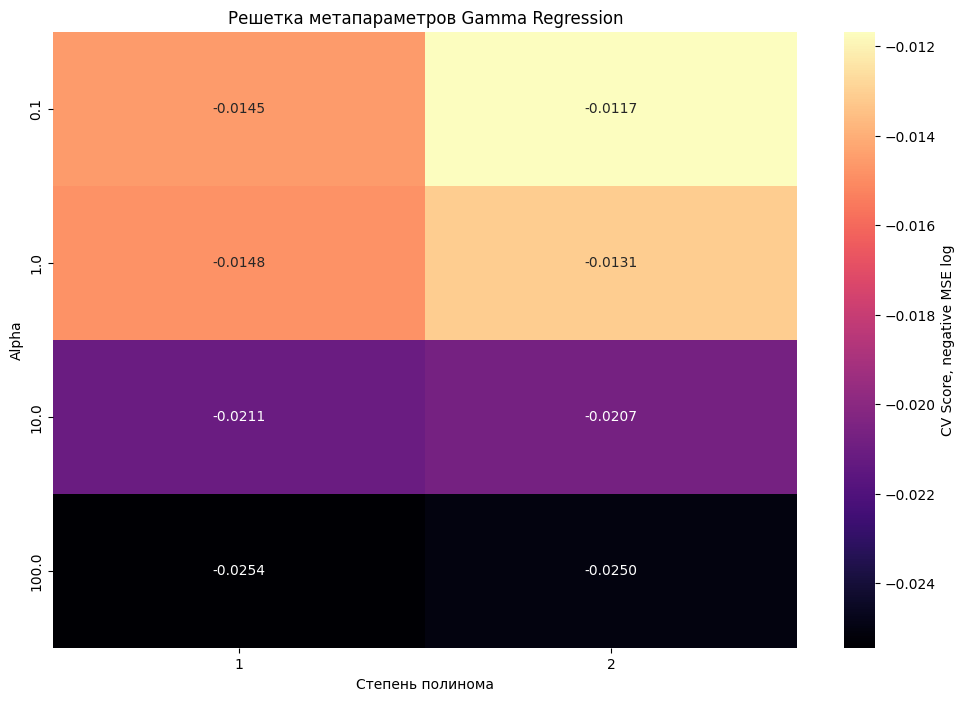

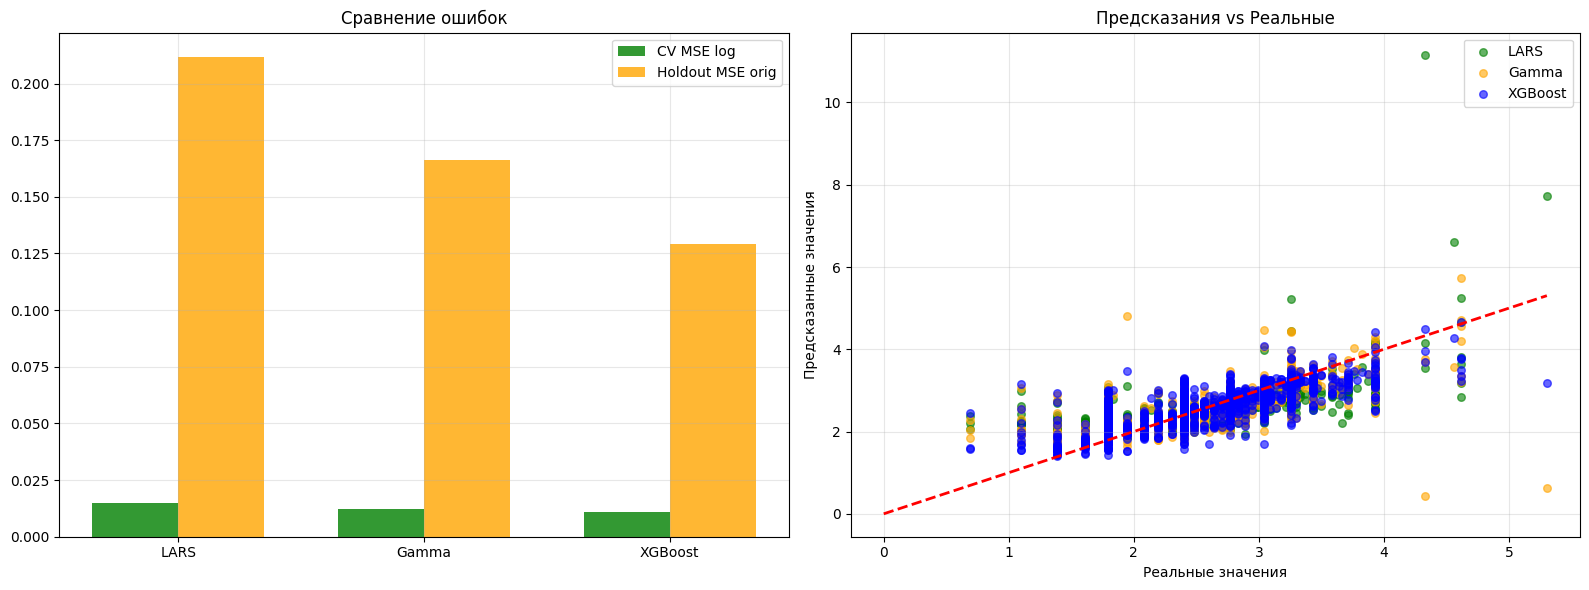

In [ ]:
lars_pred_log = best_lars.predict(X_holdout_scaled)
lars_pred = np.expm1(lars_pred_log)
lars_mse_original = mean_squared_error(np.expm1(y_holdout_log), lars_pred)
lars_r2_original = r2_score(np.expm1(y_holdout_log), lars_pred)

gamma_pred = np.expm1(gamma_holdout_pred_log)
gamma_mse_original = mean_squared_error(np.expm1(y_holdout_log), gamma_pred)

xgb_pred = np.expm1(xgb_pred_log)
xgb_mse_original = mean_squared_error(np.expm1(y_holdout_log), xgb_pred)
xgb_r2_original = r2_score(np.expm1(y_holdout_log), xgb_pred)

comparison = pd.DataFrame({
    'Модель': ['LARS', 'Gamma Regression', 'XGBoost'],
    'CV MSE log': [best_cv_score_log, gamma_cv_mse_log, -cross_val_score(xgb_model, X_train_xgb, y_train_log, cv=5, scoring='neg_mean_squared_error').mean()],
    'Holdout MSE orig': [lars_mse_original, gamma_mse_original, xgb_mse_original],
    'R² orig': [lars_r2_original, gamma_r2_original, xgb_r2_original]
})
print(comparison)

results_df = pd.DataFrame(halving_search.cv_results_)
pivot_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_gamma__alpha',
    columns='param_poly__degree',
    aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='magma', 
           cbar_kws={'label': 'CV Score, negative MSE log'})
plt.title('Решетка метапараметров Gamma Regression')
plt.xlabel('Степень полинома')
plt.ylabel('Alpha')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
models = ['LARS', 'Gamma', 'XGBoost']
cv_mse_log = [best_cv_score_log, gamma_cv_mse_log, comparison.loc[2, 'CV MSE log']]
holdout_mse_orig = [lars_mse_original, gamma_mse_original, xgb_mse_original]

x = np.arange(len(models))
width = 0.35
ax[0].bar(x - width/2, cv_mse_log, width, label='CV MSE log', alpha=0.8, color='green')
ax[0].bar(x + width/2, holdout_mse_orig, width, label='Holdout MSE orig', alpha=0.8, color='orange')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].set_title('Сравнение ошибок')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].scatter(np.expm1(y_holdout_log), lars_pred, alpha=0.6, label='LARS', s=30, color='green')
ax[1].scatter(np.expm1(y_holdout_log), gamma_pred, alpha=0.6, label='Gamma', s=30, color='orange')
ax[1].scatter(np.expm1(y_holdout_log), xgb_pred, alpha=0.6, label='XGBoost', s=30, color='blue')
ax[1].plot([0, np.expm1(y_holdout_log).max()], [0, np.expm1(y_holdout_log).max()], 'r--', lw=2)
ax[1].set_xlabel('Реальные значения')
ax[1].set_ylabel('Предсказанные значения')
ax[1].set_title('Предсказания vs Реальные')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()